# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** Abiyyu Rasyiq Muhadzzib
- **Email:** abiyyu.rm12@gmail.com
- **ID Dicoding:** abiyyu_rasyiq

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren pertumbuhan revenue setiap bulannya?
2. Produk apa yang paling berkontribusi terhadap revenue?
3. Bagaimana kontribusi masing-masing segmen terhadap total revenue?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

## Data Wrangling

### Gathering Data

Untuk menjawab pertanyaan bisnis tersebut maka perlu beberapa dataset berikut ini:
1. **Customers Dataset**
2. **Orders Dataset**
3. **Payment Dataset**
4. **Order Items Dataset**
5. **Product Dataset**
6. **Product Categoty Name Dataset**

In [ ]:
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [ ]:
customers_df = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
orders_df = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
payments_df = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv")
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
items_df = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv")
items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
products_df = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
name_product_df = pd.read_csv("/kaggle/input/brazilian-ecommerce/product_category_name_translation.csv")
name_product_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Assessing Data

Tahap assessing dataset dilakukan untuk mengecek kualitas setiap dataset. Hal yang dilakukan:
- cek missing velue
- cek duplicate data
- cek invalid value
- cek outlier velue

**Customers Dataset**

In [ ]:
print("Informasi Dataset\n")
customers_df.info()

Informasi Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Berdasarkan informasi dataset ada beberapa insight yang didapat:
* Pada dataset tidak terdapat missing value
* Dataset juga tidak memiliki sebuah kolom dapat menghasilkan sebuah anomali pada nilainya.

Selanjutnya melakukan pengecekan duplikasi data

In [ ]:
print("Jumlah data duplikat: ", customers_df.duplicated().sum())

Jumlah data duplikat:  0


**Insight:**
* Informasi dataset berisi id, kota, dan state setiap customers.
* Pada dataset customers tidak terdapat missing value dan data duplikat.

Ini menandakan bahwa dataset customets sudah siap untuk di analisis.

**Orders Dataset**

In [ ]:
print("Informasi Dataset\n")
orders_df.info()

Informasi Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Perdasarkan informasi dataset ada beberapa insight yang didapat:
* Pada dataset tidak terdapat kolom yang memiliki nilai numerik
* Terdapat missing values pada dataset tersebut

Selanjutnya pengecekan missing values yang ditemukan pada dataset.

In [ ]:
print("Jumlah missing values di setiap kolom dataset ORDER")
orders_df.isna().sum()

Jumlah missing values di setiap kolom dataset ORDER


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


insight:
* Missing value pada kolom `order_approved_at` sebanyak 160. Menandakan bahwa mungkin ada order yang tidak mendapatakn approved, tidak terdata, hilang, atau kendala lainnya.
* Missing value pada kolom `order_delivered_carrier_date` sebanyak 1783. Menandakan bahwa mungkin pesanan yang tidak sampai ke mitra logistik, tidak terdata, hilang, atau kendala lainnya.
* Missing value pada kolom `order_estimated_delivery_date` sebanyak 2965. Menandakan bahwa ada pesanan yang tidak disampaikan ke pada customer, tidak terdata, atau kendala lainnya.

**Payments Dataset**

In [ ]:
print("Informasi Dataset\n")
payments_df.info()

Informasi Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


Berdasarkan informasi dataset ada beberapa insight:
* Terdapat 3 kolom numerik yaitu `payments_sequential`, `payment_installments`, `payment_value`
* Terdapat 2 kolom kategori yaitu `order_id`, `payment_type`
* Tidak terdapat missing value pada dataset.

Selanjutnya cek data duplikasi

In [ ]:
print("Jumlah data duplikat: ", payments_df.duplicated().sum())

Jumlah data duplikat:  0


**Insight:**
* Tidak terdapat data yang duplikasi pada dataset

Selanjutnya statistik deskriptif untuk melihat apakah ada tanda-tanda outlier pada dataset.

In [ ]:
print("Statistik Deskriptif Dataset\n")
payments_df.describe()

Statistik Deskriptif Dataset



,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Insight:**
* Berdasarakan statistik deskriptif terdapat tanda-tanda anomali atau outlier pada dataset.

Maka dari itu dilakukan pengecekan dengan boxplot untuk memvalidasi hasil.


 Jumlah outlier pada kolom payment_sequential: 4526


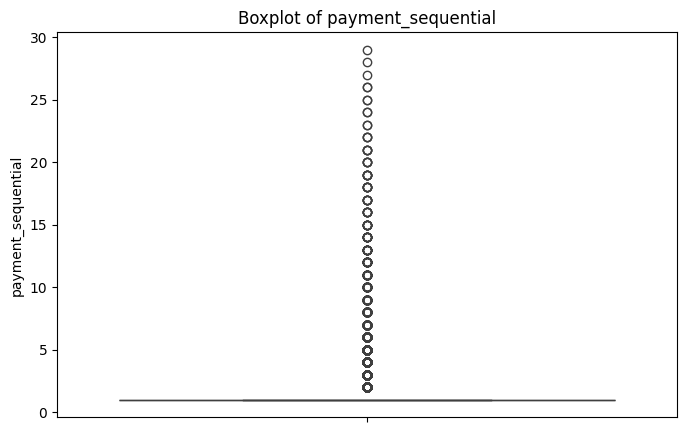


 Jumlah outlier pada kolom payment_installments: 6313


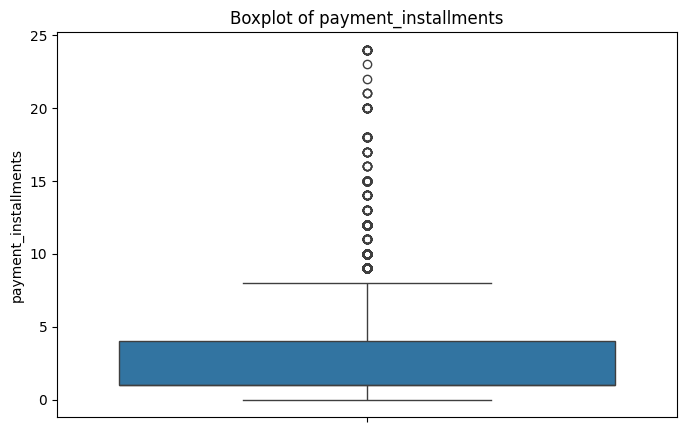


 Jumlah outlier pada kolom payment_value: 7981


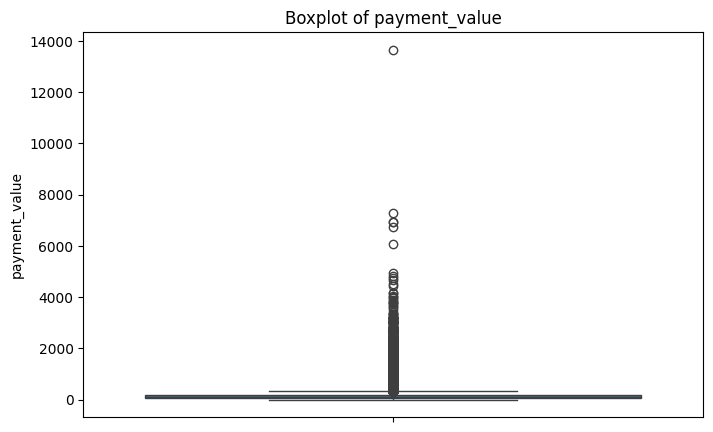

In [ ]:
cols = ['payment_sequential', 'payment_installments', 'payment_value']

for col in cols:
  iqr = payments_df.loc[:, col].quantile(0.75) - payments_df.loc[:, col].quantile(0.25)
  upper_bound = payments_df.loc[:, col].quantile(0.75) + 1.5 * iqr
  lower_bound = payments_df.loc[:, col].quantile(0.25) - 1.5 * iqr
  outliers = payments_df.loc[(payments_df.loc[:, col] > upper_bound) | (payments_df.loc[:, col] < lower_bound)]
  print(f"\n Jumlah outlier pada kolom {col}: {outliers.shape[0]}")

  plt.figure(figsize=(8, 5))
  sns.boxplot(y=payments_df[col])
  plt.title(f'Boxplot of {col}')
  plt.ylabel(col)
  plt.show()

**Insight:**
* Berdasarakan boxplot tervalidasinya oulier pada ketiga kolom
* Kolom `payment_sequential` terdapat 4526 outlier (4% dari dataset)
* Kolom `payment_installments` terdapat 6313 outlier (6% dari dataset)
* kolom `payment_value` terdapat 7981 outlier (7% dari dataset)

**Order Item Dataset**

In [ ]:
print("Informasi Dataset\n")
items_df.info()

Informasi Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


Berdasarakan informasi dataset ada beberapa insight:
* Dataset terdari dari 3 kolom numerik dan 4 kolom dataset.
* Tidak terdapat missing value pada setiap dataset.

Selanjutnya pengecekan duplikasi data

In [ ]:
print("Jumlah data duplikat: ", items_df.duplicated().sum())

Jumlah data duplikat:  0


**Insight:**
* Tidak terdapat data duplikasi pada dataset

Selanjutnya melihat statistik deskriptif dataset untuk melihat tanda-tanda anomali

In [ ]:
print("Statistik Deskriptif Dataset\n")
items_df.describe()

Statistik Deskriptif Dataset



,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
* Terdapat tanda-tanda anomali atau outlier pada dataset terutama kolom `price` dan `freight_value`

Kemudian dilakukan visualisasi boxplot untuk memvalidasi tanda-tanda outlier


 Jumlah outlier pada kolom price: 8427


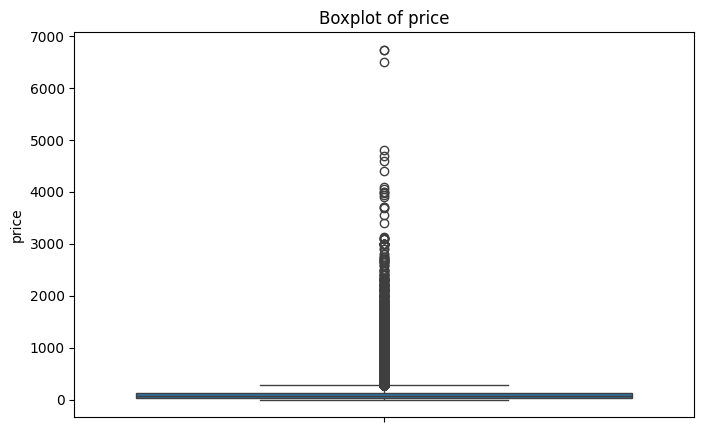


 Jumlah outlier pada kolom freight_value: 12134


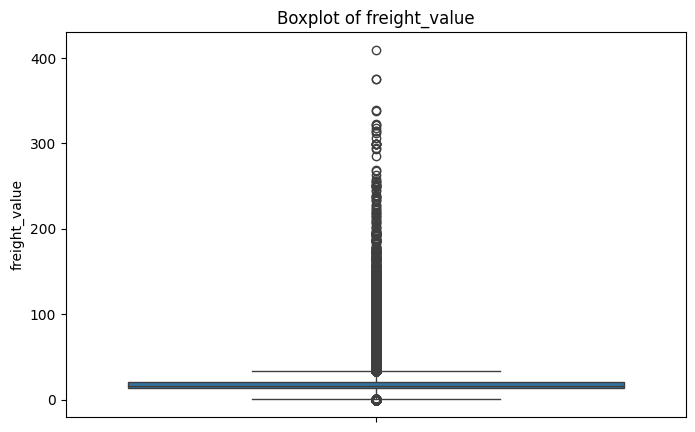

In [ ]:
cols = ['price', 'freight_value']

for col in cols:
  iqr = items_df.loc[:, col].quantile(0.75) - items_df.loc[:, col].quantile(0.25)
  upper_bound = items_df.loc[:, col].quantile(0.75) + 1.5 * iqr
  lower_bound = items_df.loc[:, col].quantile(0.25) - 1.5 * iqr
  outliers = items_df.loc[(items_df.loc[:, col] > upper_bound) | (items_df.loc[:, col] < lower_bound)]
  print(f"\n Jumlah outlier pada kolom {col}: {outliers.shape[0]}")

  plt.figure(figsize=(8, 5))
  sns.boxplot(y=items_df[col])
  plt.title(f'Boxplot of {col}')
  plt.ylabel(col)
  plt.show()

**Insight:**
* Tervalidasinya outlier pada kedua kolom dataset
* pada kolom `price` terdapat 8427 outlier ( 7% dari dataset)
* Pada kolom `freight_value` terdapat 12134 outlier ( 10% dari dataset)

**Product Dataset**

In [ ]:
print("Informasi Dataset\n")
products_df.info()

Informasi Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**

Berdasarkan informasi dari dataset product, terdapat missing value pada kolom yang akan digunakan untuk analisis produk. Kolom seperti `product_categoty__name` sangat penting dalam analisis ini.

In [ ]:
print("Jumlah missing values di setiap kolom dataset Products")
products_df.isna().sum()

Jumlah missing values di setiap kolom dataset Products


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


**insight:**

Berdasarkan tabel diatas, terutama kolom `product_category_name` terdapat 610 data yang hilang.

In [ ]:
print("Jumlah data duplikat: ", products_df.duplicated().sum())

Jumlah data duplikat:  0


**Insight:**

* Tidak terdapat data duplikat pada dataset ini

**Berikut adalah rangkuman dari tahap Assessing Data**
| Dataset | Informasi Dataset | Missing Value | Duplicate Data | Outlier |
|--|--|--|--|--|
| Customer Dataset | 99441 entries <br> dengan 1 numerik dan 4 kategori | 0 Missing Value | 0 Duplikate  | 0 outlier |
| Orders Dataset | 99441 entries <br> dengan 8 kolom kategori | `oreder_approved_at`: 160  value <br> `order_delivered_carrier_date` : 1783 value <br> `order_delivered_customers_date` : 2965 value | 0 Duplicate | 0 Outlier
| Payments Dataset | 103886 entries <br> dengan 3 numerik dan 2 kategori | 0 Missing Value | 0 Duplikate | `payment_sequential`: 4526 outlier <br> `payment_installments`: 6313 outlier <br> `payment_value`: 7981 outlier |
| Order item Dataset | 112650 entries <br> dengan 3 numerik dan 4 kategori | 0 Missing Value | 0 Duplicate | `price`: 8427 outlier <br> `freight_value`: 12134 outlier |
| Products Dataset | 32951 entries <br> dengan 7 numerik dan 2 Kategori | `product_category_name`: 610 <br> `product_name_lenght`: 610 <br> `product_description_lenght`: 610 <br> `product_photos_qty`: 610 <br> `product_weight_g`: 2 <br> `product_length_cm`: 2 <br> `product_height_cm`: 2 <br> `product_width_cm`: 2 | 0 Duplicate | 0 Outlier


### Cleaning Data

Pada tahap ini akan dilakukan cleaning pada dataset:
1. Orders Dataset
2. Products Dataset

Tidak melakukan pembersihan Outlier karena masih dianggap sebagai outlier yang masuk akal.

**Orders Dataset**

Pada dataset ini untuk menangani missing value dilakukan filterasi pada kolom `order_status = delivered`. Hal ini agar dataset hanya berisi data yang statusnya sudah diantar.

In [ ]:
delivered_orders_df = orders_df[orders_df['order_status'] == 'delivered']
delivered_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96478 non-null  object
 1   customer_id                    96478 non-null  object
 2   order_status                   96478 non-null  object
 3   order_purchase_timestamp       96478 non-null  object
 4   order_approved_at              96464 non-null  object
 5   order_delivered_carrier_date   96476 non-null  object
 6   order_delivered_customer_date  96470 non-null  object
 7   order_estimated_delivery_date  96478 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [ ]:
print("Jumlah missing values di setiap kolom dataset Orders")
delivered_orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


Walaupun masih terdapat missing value pada dataset, hal tersebut tidak apa-apa karena data missing tersebut tidak digunakan dalam analisis untuk menjawab pertanyaan bisnis.

**Products Dataset**

Melakukan imputasi kolom `product_category_name` pada missing value dengan "unknown".

In [ ]:
products_df['product_category_name'].fillna('unknown')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Setelah mengisi missing value pada kolom `product_category_name`, Dilakukan pengecekan ulang untuk melihat apakah masih ada missing value.

In [ ]:
print("Jumlah missing values di setiap kolom dataset Products")
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


Pada `product_category_name` tidak ada missing value lagi. Walaupun terdapat missing value di kolom lain, hal tersebut tidaklah masalah karena tidak digunakan untuk menjawab pertanyaan bisnis.

## Exploratory Data Analysis (EDA)

Selanjutnya melakukan EDA untuk melihat karakteristik setiap dataset seperti, distibusi data dan ciri khas dataset

### Customers Dataset

**Jumlah Customer**

Untuk mengetahui jumlah customer yang dimiliki pada dataset

In [ ]:
print("Jumlah Customer: ", customers_df['customer_unique_id'].nunique())

Jumlah Customer:  96096


**Insight:**

Berdasarkan informasi tersebut, berarti perusahan memiliki customer sebanyak 96096 customer.

**Customer per State**

Untuk melihat persebaran customer pada setiap state

In [ ]:
customer_state = customers_df['customer_state'].value_counts().reset_index()
customer_state.columns = ['customer_state', 'count']
customer_state['percentage'] = (customer_state['count'] / customer_state['count'].sum()) * 100
customer_state

,customer_state,count,percentage
0,SP,41746,41.980672
1,RJ,12852,12.924247
2,MG,11635,11.700405
3,RS,5466,5.496727
4,PR,5045,5.073360
5,SC,3637,3.657445
6,BA,3380,3.399000
7,DF,2140,2.152030
8,ES,2033,2.044428
9,GO,2020,2.031355


**Insight:**

- Berdasarakan informasi diatas, perusahan memiliki customer yang tersebar di berbagai state
- State SP menjadi state dengan jumlah customer tertinggi mencapai 41.98%. Disusul dengan state lain seperti RJ (12.92%) dan MG (11.7%)
- Sementara itu, state PB, PI, RN, AL, SE, TO, RO, RR, AP, dan AC  menjadi state yang memiliki customer sedikit >1%

### Orders Exploratory

**Distibusi Order per Tahun**

Untuk melihat distibusi pesanan setiap tahunnya

In [ ]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

orders_df['order_year'] = orders_df['order_purchase_timestamp'].dt.year

orders_per_year = orders_df.groupby('order_year')['order_id'].count()
orders_per_year

,order_id
order_year,
2016,329
2017,45101
2018,54011


**Insight:**

- Berdasarkan dataset, data pesanan terjadi dari tahun 2016 sampai 2018
- Tahun 2018 menjadi tahun yang paling sering menerima pesanan dengan 54011 pesanan
- Namun pada tahun 2016 menjadi tahun yang sedikit menerima pesanan dengan hanya 329 pesanan saja.

Hal ini dapat mengindikasi bahwa data pesanan baru tercatat di tahun 2016 dan puncak pesanan terjadi di tahun 2018

**Distibusi `order_status`**

Melihat distibusi status pada dataset orders. Hal ini untuk melihat status pesan yang valid dan tidak valid.

In [ ]:
status = orders_df['order_status'].value_counts().reset_index()
status.columns = ['order_status', 'count']
status['percentage'] = (status['count'] / status['count'].sum()) * 100
status

,order_status,count,percentage
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


**Insight:**
- Terdapat 97% data yang berstatus `delivered`,
- Terdapat juga 1% data yang berstatus `shipped`,  dan
- Beberapa data yang dibawah 1% seperti `canceled`, `unavailable`, `invoiced`, `processing`, `created`, `approved`.

### Payment Exploratory

**Distibusi Payment Type**

Untuk melihat penyebaran tipe payment yang digunakan oleh para customer

In [ ]:
payment_type = payments_df['payment_type'].value_counts().reset_index()
payment_type.columns = ['payment_type', 'count']
payment_type['percentage'] = (payment_type['count'] / payment_type['count'].sum()) * 100
payment_type

,payment_type,count,percentage
0,credit_card,76795,73.922376
1,boleto,19784,19.043952
2,voucher,5775,5.558978
3,debit_card,1529,1.471806
4,not_defined,3,0.002888


**Insight: **
- Berdasarkan informasi diatas, customer menggunakan 4 jenis payment
- `credit_card` menjadi tipe payment yang sering digunakan oleh customer hingga 73.92%
- Sedangkan `debit_card` menjadi tipe payment yang paling sedikit digunakan oleh customer hanya 1.47%
- Pada dataset juga terdapat setidaknya 3 customer yang tidak terdefinisi menggunakan tipe payment apa

### Product Exploratory

**Distibusi Product**

Untuk melihat distibusi produk berdasarkan pembelian yang terjadi

In [ ]:
product_df = items_df.merge(
    products_df,
    on='product_id',
    how='left'
)

product_df = product_df.merge(
    name_product_df,
    on='product_category_name',
    how='left'
)

category_distribution = product_df['product_category_name_english'].value_counts().reset_index()
category_distribution.columns = ['product_category_name_english', 'count']
category_distribution['percentages'] = (category_distribution['count'] / category_distribution['count'].sum()) * 100
category_distribution


,product_category_name_english,count,percentages
0,bed_bath_table,11115,10.011439
1,health_beauty,9670,8.709907
2,sports_leisure,8641,7.783072
3,furniture_decor,8334,7.506553
4,computers_accessories,7827,7.049891
...,...,...,...
66,arts_and_craftmanship,24,0.021617
67,cds_dvds_musicals,14,0.012610
68,la_cuisine,14,0.012610
69,fashion_childrens_clothes,8,0.007206


**Insight:**
- Berdasarkan dataset, perusahaan memiliki 71 kategori produk yang berhasil terjual
- Kategori produk `bed_bath_table` Menjadi produk terlaris dengan 11115 atau 10% pembelian, disusul dengan `health_beauty` 9670 (8.7%), `sport_leisure` 8541 (7.78%), dan `furniture_decor` 8334 (7.5%)
- Sementara kategori seperti `security_and services` menjadi produk yang paling sedikit penjualannya hanya 2 kali terjadi pembelian, disusul dengan `fashion_childrens_clothes` 8 pembelian, dan `la_cuisine` serta `cds_dvds_musicals` 14 pembelian

### Order Items Dataset

**Distibusi Price**

Untuk melihat persebaran harga pada dataset order item

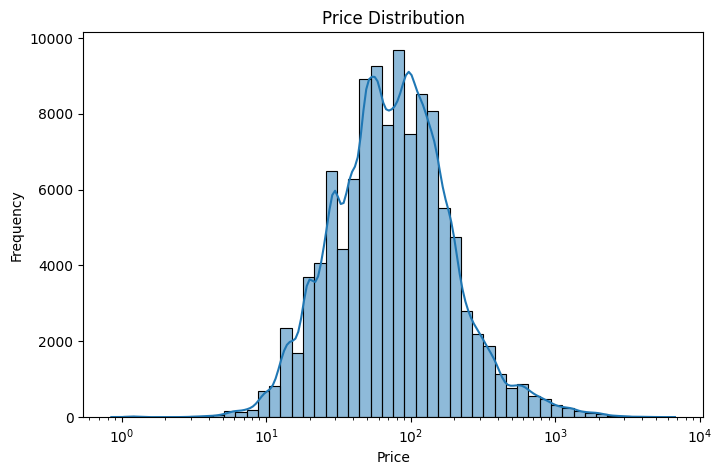

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(items_df['price'], bins=50, log_scale=True, kde=True)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

**Insight:**

- Pada skala logaritmik ini, bentuk grafik distribusi normal. Artinya, mayoritas besar item berada di kisaran harga rendah hingga menengah.
- Puncak kurva berada di sekitar angka $10^2$ (yaitu 100), Menunjukkan bahwa kisaran harga di sekitar 100 adalah harga yang paling umum atau paling sering muncul dalam dataset
- Grafik menunjukkan adanya ekor yang memanjang ke sisi kanan, menunjukkan segelintir item memiliki harga yang sangat tinggi mendekati $10^4$ (10.000)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren pertumbuhan revenue setiap bulannya?

Hal ini untuk mengetahui, bagaimana pertumbuhan revenue perusahaan sehingga dapat melakukan evaluasi setiap tahunnya. Analisis ini dilakukan per bulan agar lebih detail dalam melihat pertumbuhan trendnya.

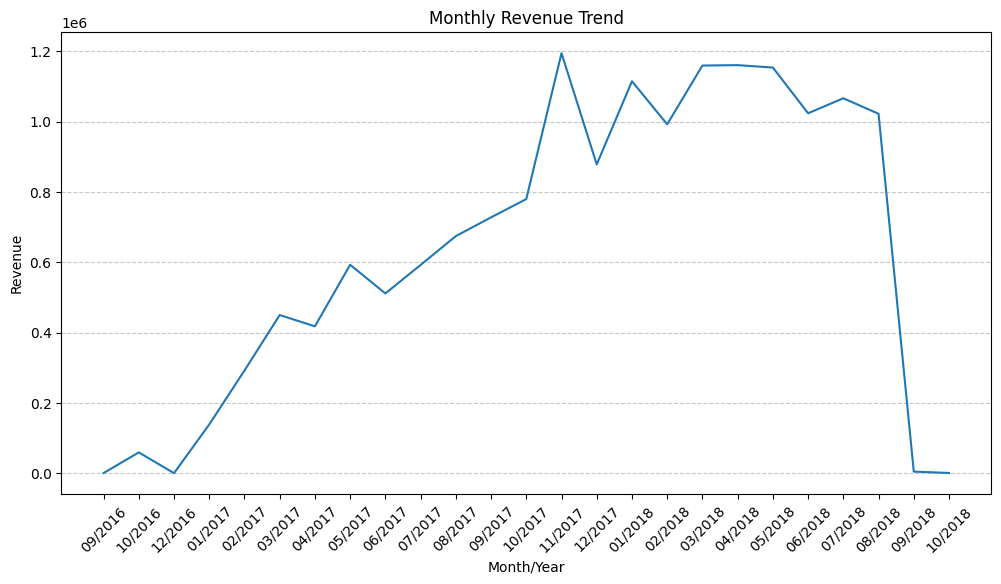

In [ ]:
revenue_df = orders_df.merge(
    payments_df,
    on='order_id',
    how='inner'
)

revenue_df['order_purchase_timestamp'] = pd.to_datetime(
    revenue_df['order_purchase_timestamp']
)

revenue_df['month_year'] = revenue_df['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = revenue_df.groupby('month_year')['payment_value'].sum().reset_index()
monthly_revenue['month_year_str'] = monthly_revenue['month_year'].dt.strftime('%m/%Y')


plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_revenue,
    x='month_year_str',
    y='payment_value'
)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month/Year')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Berdasarkan grafik tersebut, trend revenue dimulai dari bulan September 2016 hingga Agustus 2018, dengan pola pertumbuhan yang cukup signifikan sepanjang tahun 2017
- Tren puncaknya terjadi pada bulan November 2017, dimana revenue mencapai sekitar 1.200.000
- Namun, terjadi penurunan setelahnya pada Desember 2017 menjadi sekitar 880.000, atau turun sekitar 320.000 dibandingkan bulan sebelumnya
- Setelah penurunan pada Desember 2017, revenue kembali meningkat pada awal 2018 dan relatif stabil di kisaran 1.000.000 – 1.150.000 hingga pertengahan 2018

*Terlihat adanya penurunan drastis pada September 2018, yang kemungkinan menunjukkan data belum lengkap atau adanya anomali pencatatan karena nilainya mendekati nol.

### Pertanyaan 2: Produk apa yang paling berkontribusi terhadap revenue?

Ini untuk melihat dan menilai produk apa yang memiliki keuntungan terbesar bagi perusahaan. Sehingga perusahaan dapat melakukan evaluasi terhadap produk tersebut.

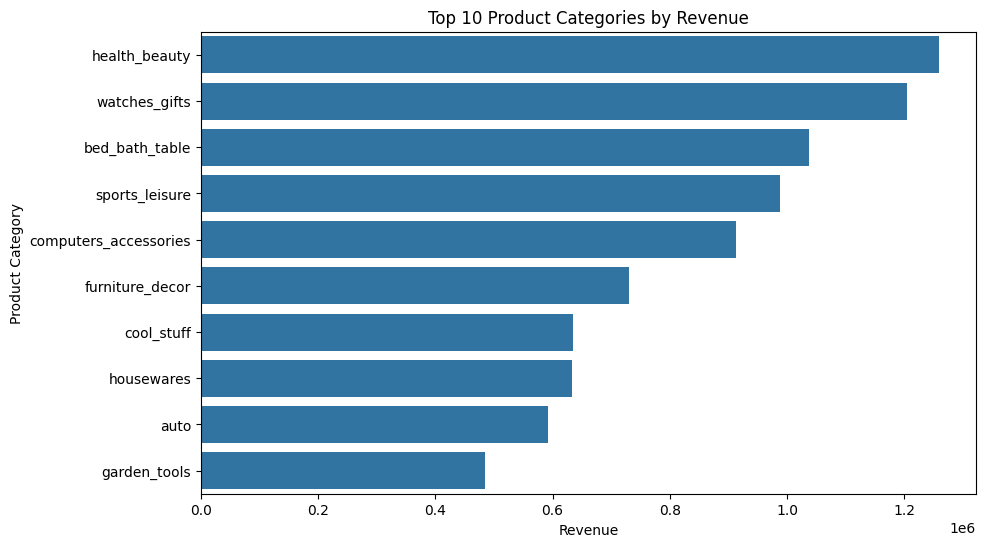

In [ ]:
product_revenue_df = orders_df.merge(
    items_df,
    on='order_id',
    how='inner'
)

product_revenue_df = product_revenue_df.merge(
    products_df,
    on='product_id',
    how='left'
)

product_revenue_df = product_revenue_df.merge(
    name_product_df,
    on='product_category_name',
    how='left'
)

product_revenue = product_revenue_df.groupby(
    'product_category_name_english'
)['price'].sum().reset_index()

top10_products = product_revenue.sort_values(
    by='price',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_products,
    x='price',
    y='product_category_name_english'
)
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.show()

**Insight:**
- Berdasarkan grafik di atas, kategori produk `health_beauty` menjadi produk dengan kontribusi revenue tertinggi hingga sekitar 1.260.000
- Kemudian diikuti oleh kategori `watches_gifts` dengan revenue sekitar 1.200.000, `bed_bath_table` sebesar sekitar 1.030.000, dan `sports_leisure` sebesar sekitar 980.000
- Kategori lain seperti `computers_accessories` dan `furniture_decor` juga memberikan kontribusi cukup besar dengan revenue masing-masing sekitar 910.000 dan 730.000
- Sementara itu, kategori dengan kontribusi paling rendah dalam top 10 adalah `garden_tools` dengan revenue sekitar 490.000

Hal ini menunjukkan bahwa produk terkait lifestyle, kesehatan, dan hadiah memiliki permintaan yang lebih tinggi dibanding kategori lainnya.

## Analisis Lanjutan (Opsional)

Analisis lanjutan menggunakan **RMF Analysis** untuk melihat segmentasi customer yang memiliki kontribusi besar terdapat perusahaan.

In [ ]:
rfm_df = orders_df.merge(
    customers_df,
    on='customer_id',
    how='inner'
)

rfm_df = rfm_df.merge(
    payments_df,
    on='order_id',
    how='inner'
)

rfm_df = rfm_df[rfm_df['order_status'] == 'delivered']

rfm_df['order_purchase_timestamp'] = pd.to_datetime(
    rfm_df['order_purchase_timestamp']
)

analysis_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (analysis_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [ ]:
def segment_customer(row):

    if row['R_score'] == 5 and row['F_score'] == 5:
        return 'Champions'

    elif row['F_score'] >= 4:
        return 'Loyal Customers'

    elif row['R_score'] >= 4:
        return 'Potential Loyalists'

    elif row['R_score'] <= 2:
        return 'At Risk'

    else:
        return 'Others'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

In [ ]:
segment_revenue = rfm.groupby('segment')['Monetary'].sum().reset_index()
segment_revenue['percentage'] = (
    segment_revenue['Monetary'] /
    segment_revenue['Monetary'].sum()
) * 100

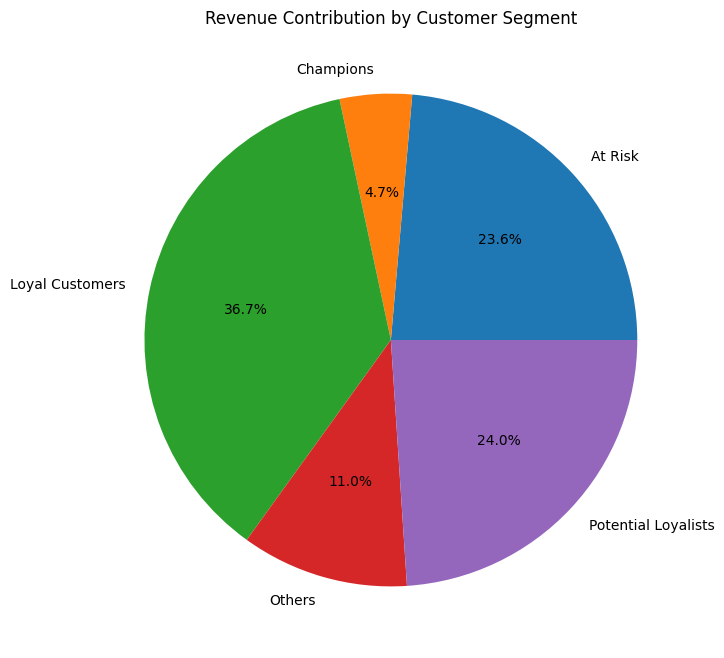

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    segment_revenue['Monetary'],
    labels=segment_revenue['segment'],
    autopct='%1.1f%%'
)

plt.title('Revenue Contribution by Customer Segment')

plt.show()

**Insight:**
- Berdasarkan grafik Revenue Contribution by Customer Segment, segmen Loyal Customers memberikan kontribusi revenue terbesar yaitu sekitar 36,7% dari total pendapatan
- Segmen Potential Loyalists berada pada posisi kedua dengan kontribusi sekitar 24,0%, diikuti oleh segmen At Risk sebesar 23,6%
- Sementara itu, segmen Others menyumbang sekitar 11,0% dari total revenue
- Segmen dengan kontribusi paling kecil adalah Champions dengan sekitar 4,7% dari total revenue

## Conclusion

**1. Tren Pertumbuhan Revenue Bulanan**

Tren revenue per bulan menunjukkan fluktuasi, namun secara keseluruhan menggambarkan pertumbuhan yang positif dari tahun 2017 hingga pertengahan 2018. Pada umumnya untuk perusahaan ini, terdapat lonjakan transaksi dan pendapatan yang signifikan pada bulan November 2017

**2. Produk yang Paling Berkontribusi terhadap Revenue**

Kategori produk yang berkaitan dengan kebutuhan rumah tangga dan gaya hidup mendominasi transaksi pembelian. Kategori bed_bath_table menjadi produk yang paling laris dengan total 11.115 pesanan, menyumbang persentase terbesar yaitu 10,01% dari total penjualan. Posisi selanjutnya secara berurutan diisi oleh produk kecantikan dan olahraga, yakni health_beauty dengan 9.670 pesanan (8,71%), sports_leisure (7,78%), serta furniture_decor (7,51%).

**3.Kontribusi Masing-Masing Segmen terhadap Total Revenue**

Dari hasil perhitungan algoritma RFM (Recency, Frequency, Monetary), terlihat jelas bahwa pelanggan setia adalah penggerak utama bisnis. Segmen Loyal Customers merupakan penyumbang revenue terbesar dengan taksiran kontribusi mencapai 36,7%. Untuk segmen pelanggan lainnya, rinciannya adalah sebagai berikut:
- Segmen Potential Loyalists berada pada posisi kedua dengan kontribusi sekitar 24,0% terhadap total revenue.
- Diikuti oleh segmen At Risk yang memberikan kontribusi cukup besar, yaitu 23,6%.
- Sementara itu, segmen Others menyumbang sekitar 11,0% dari total revenue.
- Segmen dengan kontribusi paling kecil adalah Champions dengan persentase sekitar 4,7% dari total revenue.

In [ ]:
!pip freeze > requirements.txt